# 🚗 Phone Black Box — Driving Event & Crash Classifier
## Final, dataset-aligned ML pipeline

This notebook is built specifically for the processed `master_dataset` supplied with the Phone Black Box project.

**Authoritative dataset contract**
- 21,978 preprocessed 1-second windows
- 100 Hz sampling rate
- 62 engineered features per window
- 9 driving-event classes
- Train: 15,308 | Validation: 3,268 | Test: 3,402
- Metadata files: `label_mapping.json` and `feature_metadata.json`

The notebook deliberately does **not** recreate the raw datasets. It consumes the already processed master dataset and validates that the files match the documented contract before training.

In [1]:
import os, sys, json, time, random
from pathlib import Path

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    classification_report, confusion_matrix
)
import lightgbm as lgb
import xgboost as xgb
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.set_num_threads(1)

# The notebook is normally opened from the project root or notebooks/.
DATASET_CANDIDATES = [
    Path("dataset/master_dataset"),
    Path("../dataset/master_dataset"),
    Path("./master_dataset"),
]
DATASET_DIR = next((p for p in DATASET_CANDIDATES if p.exists()), None)
if DATASET_DIR is None:
    raise FileNotFoundError(
        "master_dataset not found. Expected dataset/master_dataset or ../dataset/master_dataset."
    )

ARTIFACT_DIR = Path("artifacts_phone_black_box")
PLOT_DIR = ARTIFACT_DIR / "plots"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("LightGBM:", lgb.__version__)
print("XGBoost:", xgb.__version__)
print("Dataset:", DATASET_DIR.resolve())

Python: 3.9.6
PyTorch: 2.8.0
LightGBM: 4.6.0
XGBoost: 2.1.4
Dataset: /Users/viditagarwal/Desktop/Phone Black Box 2/dataset/master_dataset


## 1. Load the processed master dataset

The supplied dataset contains both Parquet and CSV copies. Parquet is preferred; CSV is used only as a fallback when a Parquet engine is unavailable.

The notebook uses the **split files** (`train`, `val`, `test`) as the ML source of truth.

In [2]:
def load_split(name):
    parquet = DATASET_DIR / f"{name}.parquet"
    csv = DATASET_DIR / f"{name}.csv"
    if parquet.exists():
        try:
            return pd.read_parquet(parquet)
        except ImportError:
            print(f"Parquet engine unavailable; falling back to {csv.name}")
    if csv.exists():
        return pd.read_csv(csv)
    raise FileNotFoundError(f"Missing split: {parquet} or {csv}")

train_df = load_split("train")
val_df = load_split("val")
test_df = load_split("test")

with open(DATASET_DIR / "label_mapping.json", encoding="utf-8") as f:
    label_meta = json.load(f)
with open(DATASET_DIR / "feature_metadata.json", encoding="utf-8") as f:
    feature_meta = json.load(f)

feature_cols = feature_meta["feature_names"]
label_map = {int(k): v for k, v in label_meta["label_to_name"].items()}
target_names = [label_map[i] for i in range(len(label_map))]

print(f"Train: {train_df.shape}")
print(f"Validation: {val_df.shape}")
print(f"Test: {test_df.shape}")
print(f"Total windows: {len(train_df)+len(val_df)+len(test_df):,}")
print(f"ML features: {len(feature_cols)}")
print("Classes:", label_map)

Train: (15308, 67)
Validation: (3268, 67)
Test: (3402, 67)
Total windows: 21,978
ML features: 62
Classes: {0: 'crash', 1: 'near_miss', 2: 'normal_driving', 3: 'braking', 4: 'hard_braking', 5: 'turn', 6: 'sharp_turn', 7: 'bump', 8: 'pothole'}


## 2. Dataset contract and integrity audit

This section verifies the exact processed dataset you supplied. In particular, the CSV files have 67 columns: **62 ML features + 5 metadata/label columns** (`sample_id`, `class_label`, `class_name`, `source_dataset`, `split`).

No feature engineering is silently performed here.

In [3]:
EXPECTED_FEATURE_COUNT = 62
EXPECTED_CLASSES = 9
EXPECTED_SPLIT_SIZES = {"train": 15308, "val": 3268, "test": 3402}

assert len(feature_cols) == EXPECTED_FEATURE_COUNT, f"Expected 62 features, got {len(feature_cols)}"
assert len(label_map) == EXPECTED_CLASSES, f"Expected 9 classes, got {len(label_map)}"

required_meta_cols = {"sample_id", "class_label", "class_name", "source_dataset", "split"}
for split_name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    assert required_meta_cols.issubset(df.columns), f"{split_name}: missing metadata columns"
    missing = [c for c in feature_cols if c not in df.columns]
    assert not missing, f"{split_name}: missing features: {missing}"
    assert np.isfinite(df[feature_cols].to_numpy(dtype=np.float64)).all(), f"{split_name}: NaN/Inf detected"
    assert set(df["class_label"].unique()).issubset(label_map.keys())
    assert set(df["class_name"].unique()).issubset(set(label_map.values()))
    assert set(df["split"].unique()) == {split_name}, f"{split_name}: split column mismatch"
    assert len(df) == EXPECTED_SPLIT_SIZES[split_name], f"{split_name}: unexpected row count"

# IDs must be unique and disjoint across the supplied partitions.
id_sets = {n: set(d["sample_id"].astype(str)) for n,d in [("train",train_df),("val",val_df),("test",test_df)]}
assert all(len(id_sets[n]) == len(d) for n,d in [("train",train_df),("val",val_df),("test",test_df)])
assert not (id_sets["train"] & id_sets["val"])
assert not (id_sets["train"] & id_sets["test"])
assert not (id_sets["val"] & id_sets["test"])

print("✓ 62 feature columns verified")
print("✓ 9 labels verified")
print("✓ Split sizes verified")
print("✓ No NaN/Inf values")
print("✓ sample_id unique within every split")
print("✓ sample_id disjoint across train/val/test")
print("\nSource distribution:")
print(pd.concat([train_df, val_df, test_df])["source_dataset"].value_counts().to_string())

✓ 62 feature columns verified
✓ 9 labels verified
✓ Split sizes verified
✓ No NaN/Inf values
✓ sample_id unique within every split
✓ sample_id disjoint across train/val/test

Source distribution:
source_dataset
VZCrash                   16814
Combined_Anomalies         4246
road_accident_imu_8000      500
Combined_Normal             418


## 3. Class distribution and source coverage

The processed master dataset combines multiple source datasets. Source identity is retained for auditability but is **not used as an input feature**, preventing the model from learning the dataset source instead of driving behavior.

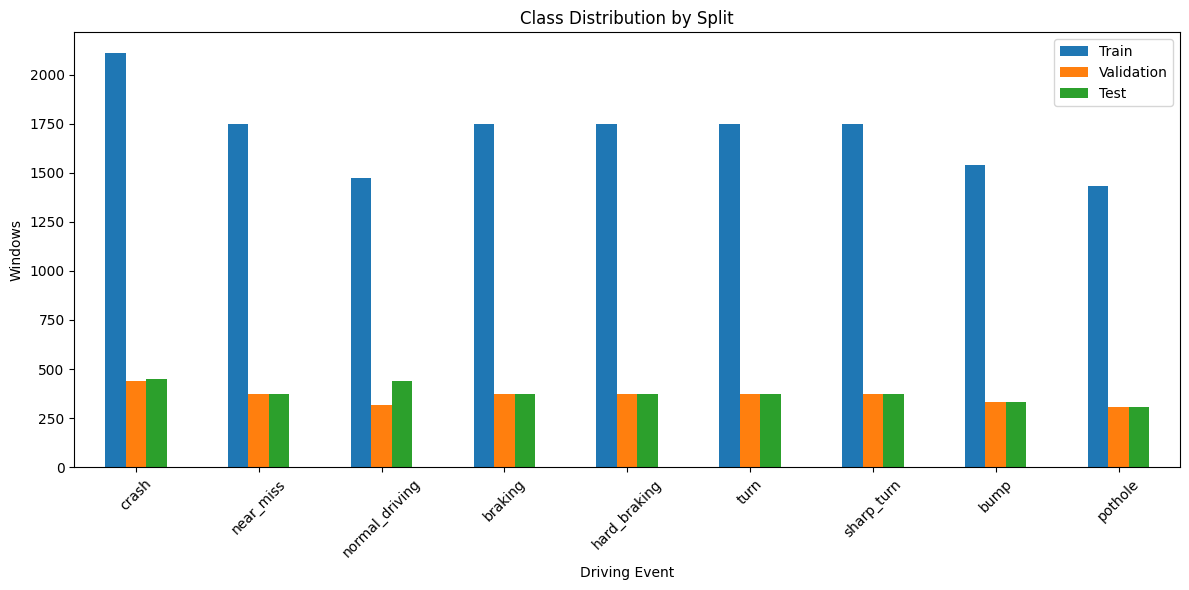

Class counts:
                Train  Validation  Test
class_name                             
crash            2110         439   451
near_miss        1750         375   375
normal_driving   1475         319   438
braking          1750         375   375
hard_braking     1750         375   375
turn             1750         375   375
sharp_turn       1750         375   375
bump             1540         330   330
pothole          1433         305   308

Source × class coverage:
class_name              crash  near_miss  normal_driving  braking  \
source_dataset                                                      
Combined_Anomalies          0          0               0        0   
Combined_Normal             0          0             418        0   
VZCrash                  2500       2500            1814     2500   
road_accident_imu_8000    500          0               0        0   

class_name              hard_braking  turn  sharp_turn  bump  pothole  
source_dataset                   

In [4]:
combined = pd.concat([train_df, val_df, test_df], ignore_index=True)

class_counts = pd.DataFrame({
    "Train": train_df["class_name"].value_counts(),
    "Validation": val_df["class_name"].value_counts(),
    "Test": test_df["class_name"].value_counts(),
}).fillna(0).astype(int).reindex(target_names)

fig, ax = plt.subplots(figsize=(12, 6))
class_counts.plot(kind="bar", ax=ax)
ax.set_title("Class Distribution by Split")
ax.set_xlabel("Driving Event")
ax.set_ylabel("Windows")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(PLOT_DIR / "class_distribution.png", dpi=160)
plt.show()
plt.close()

source_counts = pd.crosstab(combined["source_dataset"], combined["class_name"]).reindex(columns=target_names, fill_value=0)
print("Class counts:")
print(class_counts)
print("\nSource × class coverage:")
print(source_counts)

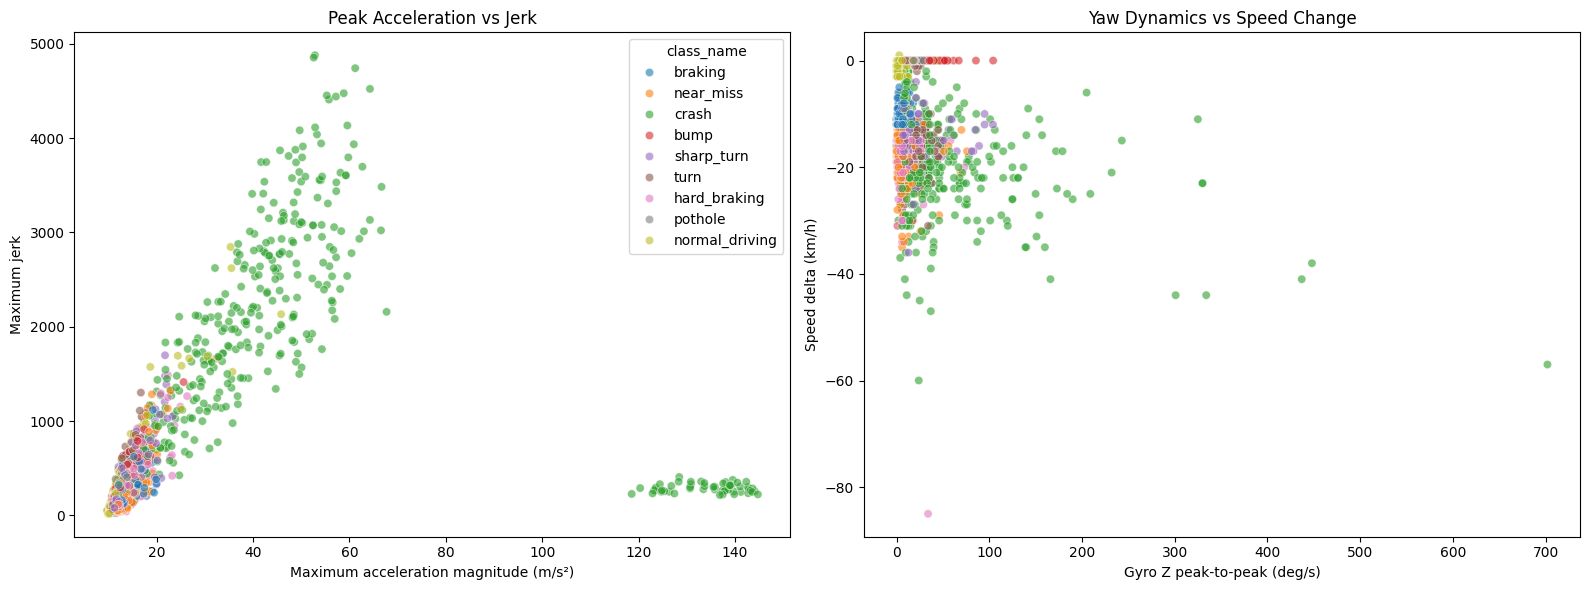

In [5]:
sample = train_df.sample(min(2500, len(train_df)), random_state=SEED)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=sample, x="acc_mag_max", y="jerk_max", hue="class_name", alpha=0.6, ax=axes[0])
axes[0].set_title("Peak Acceleration vs Jerk")
axes[0].set_xlabel("Maximum acceleration magnitude (m/s²)")
axes[0].set_ylabel("Maximum jerk")

sns.scatterplot(data=sample, x="gyro_z_p2p", y="speed_delta", hue="class_name", alpha=0.6, ax=axes[1], legend=False)
axes[1].set_title("Yaw Dynamics vs Speed Change")
axes[1].set_xlabel("Gyro Z peak-to-peak (deg/s)")
axes[1].set_ylabel("Speed delta (km/h)")

plt.tight_layout()
plt.savefig(PLOT_DIR / "kinematic_signatures.png", dpi=160)
plt.show()
plt.close()

## 4. Feature contract and preprocessing

The master dataset already contains the final 62 engineered features. Their order comes directly from `feature_metadata.json`.

**Important:** tree models use the raw engineered features. The neural model uses a `StandardScaler` fitted **only on the training split**. The exact feature order and scaler parameters are exported for deployment.

In [6]:
X_train_raw = train_df[feature_cols].astype(np.float32)
y_train = train_df["class_label"].to_numpy(dtype=np.int64)
X_val_raw = val_df[feature_cols].astype(np.float32)
y_val = val_df["class_label"].to_numpy(dtype=np.int64)
X_test_raw = test_df[feature_cols].astype(np.float32)
y_test = test_df["class_label"].to_numpy(dtype=np.int64)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw).astype(np.float32)
X_val = scaler.transform(X_val_raw).astype(np.float32)
X_test = scaler.transform(X_test_raw).astype(np.float32)

scaler_payload = {
    "features": feature_cols,
    "mean": scaler.mean_.tolist(),
    "scale": scaler.scale_.tolist(),
    "num_features": len(feature_cols),
    "fit_split": "train_only",
    "formula": "(x - mean) / scale"
}
with open(ARTIFACT_DIR / "scaler_params.json", "w", encoding="utf-8") as f:
    json.dump(scaler_payload, f, indent=2)

contract = {
    "num_features": len(feature_cols),
    "feature_names": feature_cols,
    "feature_order_is_strict": True,
    "sampling_rate_hz": label_meta["sampling_rate_hz"],
    "window_size_samples": label_meta["window_size_samples"],
    "window_duration_seconds": label_meta["window_duration_seconds"],
    "units": label_meta["units"],
    "tree_model_preprocessing": "none",
    "neural_model_preprocessing": "StandardScaler fitted on train only"
}
with open(ARTIFACT_DIR / "feature_contract.json", "w", encoding="utf-8") as f:
    json.dump(contract, f, indent=2)

print("Feature matrix shapes:", X_train_raw.shape, X_val_raw.shape, X_test_raw.shape)
print("✓ scaler_params.json exported")
print("✓ feature_contract.json exported")

Feature matrix shapes: (15308, 62) (3268, 62) (3402, 62)
✓ scaler_params.json exported
✓ feature_contract.json exported


## 5. Model A — LightGBM

LightGBM is evaluated on the **validation set only** during development. The test set remains untouched until the final benchmark.

LightGBM training time: 14.34s
                precision    recall  f1-score   support

         crash      0.951     0.966     0.958       439
     near_miss      0.697     0.608     0.650       375
normal_driving      0.991     1.000     0.995       319
       braking      0.966     0.995     0.980       375
  hard_braking      0.687     0.720     0.703       375
          turn      0.942     0.960     0.951       375
    sharp_turn      0.984     0.989     0.987       375
          bump      0.808     0.791     0.799       330
       pothole      0.779     0.797     0.788       305

      accuracy                          0.872      3268
     macro avg      0.867     0.869     0.868      3268
  weighted avg      0.869     0.872     0.870      3268



/Users/viditagarwal/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


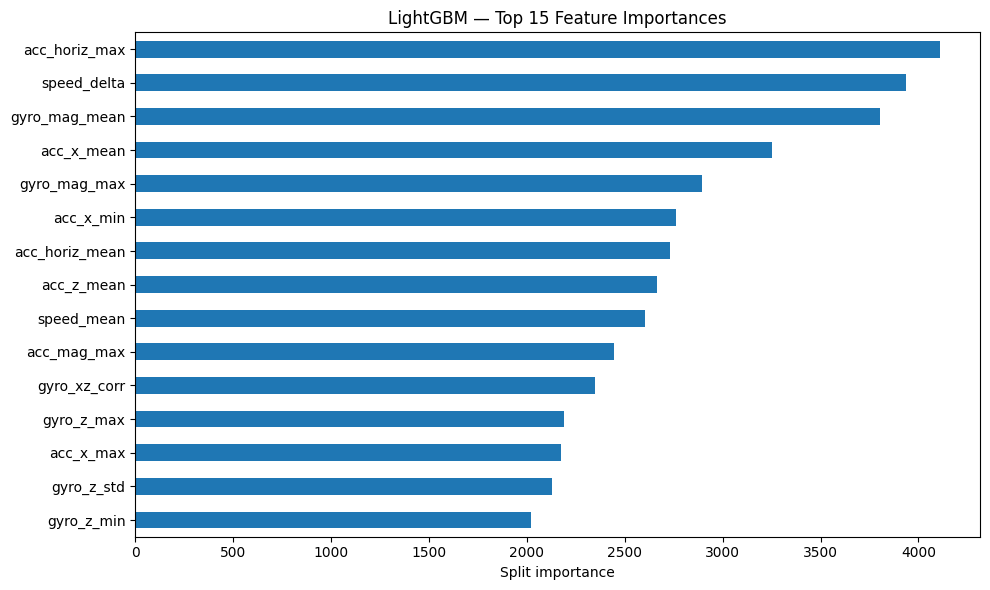

In [7]:
lgb_model = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=len(label_map),
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=9,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1,
    verbosity=-1
)

start = time.perf_counter()
lgb_model.fit(
    X_train_raw, y_train,
    eval_set=[(X_val_raw, y_val)],
    callbacks=[lgb.early_stopping(30, verbose=False)]
)
print(f"LightGBM training time: {time.perf_counter()-start:.2f}s")
y_val_lgb = lgb_model.predict(X_val_raw)
print(classification_report(y_val, y_val_lgb, target_names=target_names, digits=3, zero_division=0))

importance = pd.Series(lgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(10, 6))
importance.sort_values().plot(kind="barh", ax=ax)
ax.set_title("LightGBM — Top 15 Feature Importances")
ax.set_xlabel("Split importance")
plt.tight_layout()
plt.savefig(PLOT_DIR / "lightgbm_feature_importance.png", dpi=160)
plt.show()
plt.close()

## 6. Model B — XGBoost

XGBoost follows the same validation-only development protocol.

In [8]:
xgb_model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=len(label_map),
    n_estimators=800,
    learning_rate=0.03,
    max_depth=8,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1,
    tree_method="hist",
    eval_metric="mlogloss"
)

start = time.perf_counter()
xgb_model.fit(
    X_train_raw, y_train,
    eval_set=[(X_val_raw, y_val)],
    verbose=False
)
print(f"XGBoost training time: {time.perf_counter()-start:.2f}s")
y_val_xgb = xgb_model.predict(X_val_raw)
print(classification_report(y_val, y_val_xgb, target_names=target_names, digits=3, zero_division=0))

XGBoost training time: 23.08s
                precision    recall  f1-score   support

         crash      0.951     0.975     0.963       439
     near_miss      0.701     0.613     0.654       375
normal_driving      0.994     1.000     0.997       319
       braking      0.966     0.992     0.979       375
  hard_braking      0.693     0.715     0.703       375
          turn      0.943     0.968     0.955       375
    sharp_turn      0.987     0.992     0.989       375
          bump      0.796     0.794     0.795       330
       pothole      0.778     0.780     0.779       305

      accuracy                          0.873      3268
     macro avg      0.868     0.870     0.868      3268
  weighted avg      0.870     0.873     0.871      3268



## 7. Model C — Lightweight neural network for mobile deployment

This is a small tabular MLP. It is intentionally lightweight and receives the standardized 62-feature vector.

The validation objective prioritizes **Crash Recall** and then Macro F1 because Phone Black Box is an emergency-detection system.

Epoch 01 | loss=1.1752 | val macro-F1=0.7345 | val crash recall=0.9681
Epoch 05 | loss=0.7051 | val macro-F1=0.7900 | val crash recall=0.9590
Epoch 10 | loss=0.6620 | val macro-F1=0.7909 | val crash recall=0.9658
Epoch 15 | loss=0.6497 | val macro-F1=0.8152 | val crash recall=0.9590
Epoch 20 | loss=0.6275 | val macro-F1=0.8230 | val crash recall=0.9590
Early stopping at epoch 20


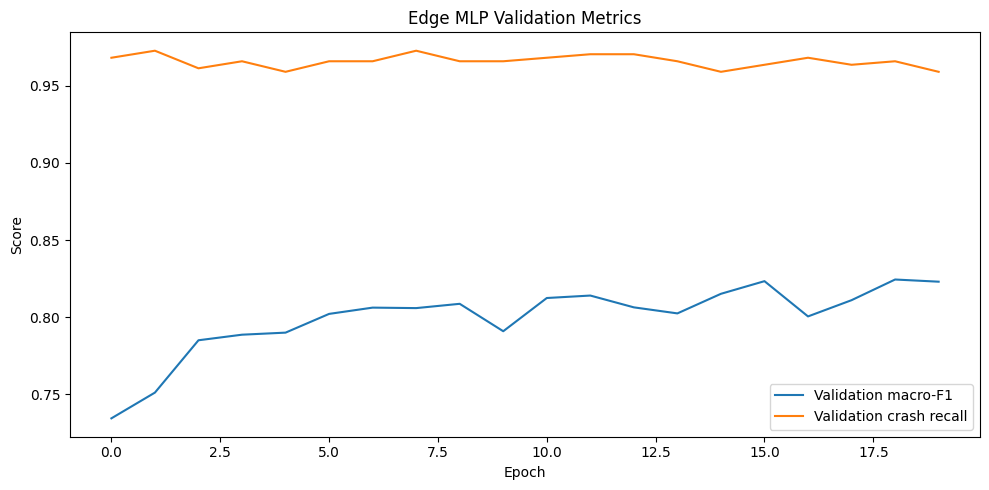

In [9]:
class EdgeDrivingMLP(nn.Module):
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.25),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(0.20),
            nn.Linear(128, 64), nn.GELU(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EdgeDrivingMLP(len(feature_cols), len(label_map)).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = optim.AdamW(model.parameters(), lr=0.002, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40)

train_loader = DataLoader(TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)), batch_size=256, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val)), batch_size=512, shuffle=False)

crash_id = next(k for k,v in label_map.items() if v == "crash")
history = {"train_loss": [], "val_macro_f1": [], "val_crash_recall": []}
best_state = None
best_score = -np.inf
stale = 0

for epoch in range(1, 41):
    model.train()
    total_loss = 0.0
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(bx), by)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(bx)
    scheduler.step()

    model.eval()
    val_preds = []
    with torch.no_grad():
        for bx, _ in val_loader:
            val_preds.append(torch.argmax(model(bx.to(device)), dim=1).cpu().numpy())
    val_preds = np.concatenate(val_preds)
    val_macro_f1 = f1_score(y_val, val_preds, average="macro")
    val_crash_recall = recall_score(y_val, val_preds, labels=[crash_id], average="macro", zero_division=0)
    score = 0.70 * val_crash_recall + 0.30 * val_macro_f1

    history["train_loss"].append(total_loss / len(X_train))
    history["val_macro_f1"].append(val_macro_f1)
    history["val_crash_recall"].append(val_crash_recall)

    if score > best_score:
        best_score = score
        best_state = {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}
        stale = 0
    else:
        stale += 1

    if epoch == 1 or epoch % 5 == 0:
        print(f"Epoch {epoch:02d} | loss={total_loss/len(X_train):.4f} | val macro-F1={val_macro_f1:.4f} | val crash recall={val_crash_recall:.4f}")
    if stale >= 8:
        print("Early stopping at epoch", epoch)
        break

model.load_state_dict(best_state)
model.eval()
with torch.no_grad():
    y_val_mlp = torch.argmax(model(torch.from_numpy(X_val).to(device)), dim=1).cpu().numpy()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history["val_macro_f1"], label="Validation macro-F1")
ax.plot(history["val_crash_recall"], label="Validation crash recall")
ax.set_xlabel("Epoch")
ax.set_ylabel("Score")
ax.set_title("Edge MLP Validation Metrics")
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "mlp_validation_history.png", dpi=160)
plt.show()
plt.close()

## 8. Validation model comparison and deployment decision

The validation set is used to compare models. The test set is still untouched.

The safety score is:

**0.70 × Crash Recall + 0.30 × Macro F1**

This is a project-specific selection heuristic, not a clinical or certified safety standard.

In [10]:
def metric_row(y_true, y_pred, name):
    near_id = next(k for k,v in label_map.items() if v == "near_miss")
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "crash_recall": recall_score(y_true, y_pred, labels=[crash_id], average="macro", zero_division=0),
        "near_miss_recall": recall_score(y_true, y_pred, labels=[near_id], average="macro", zero_division=0),
    }

val_results = pd.DataFrame([
    metric_row(y_val, y_val_lgb, "LightGBM"),
    metric_row(y_val, y_val_xgb, "XGBoost"),
    metric_row(y_val, y_val_mlp, "Edge MLP"),
])
val_results["safety_score"] = 0.70 * val_results["crash_recall"] + 0.30 * val_results["macro_f1"]
val_results = val_results.sort_values("safety_score", ascending=False).reset_index(drop=True)
print(val_results.to_string(index=False))
print("\nValidation safety leader:", val_results.iloc[0]["model"])

# The MLP remains the explicit mobile/ONNX candidate because this notebook's deployment path targets ONNX Runtime.
print("\nMobile deployment candidate: Edge MLP")
if val_results.iloc[0]["model"] != "Edge MLP":
    print("NOTE: another model has a better validation safety score. Keep that model for offline benchmarking, but do not claim the MLP is the overall best model.")

   model  accuracy  macro_f1  weighted_f1  crash_recall  near_miss_recall  safety_score
 XGBoost  0.872705  0.868364     0.870934      0.974943          0.613333      0.942969
LightGBM  0.871787  0.867933     0.870180      0.965831          0.608000      0.936462
Edge MLP  0.824663  0.814056     0.820808      0.970387          0.520000      0.923488

Validation safety leader: XGBoost

Mobile deployment candidate: Edge MLP
NOTE: another model has a better validation safety score. Keep that model for offline benchmarking, but do not claim the MLP is the overall best model.


## 9. Final test benchmark — run only after model development

This is the first point where the test set is used for model performance reporting.

/Users/viditagarwal/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


   model  accuracy  macro_f1  weighted_f1  crash_recall  near_miss_recall
LightGBM  0.825985  0.813176     0.824682      0.980044          0.549333
 XGBoost  0.834509  0.822786     0.833133      0.982262          0.576000
Edge MLP  0.801587  0.784365     0.796730      0.982262          0.448000

=== Edge MLP classification report ===
                precision    recall  f1-score   support

         crash      0.895     0.982     0.937       451
     near_miss      0.651     0.448     0.531       375
normal_driving      0.926     0.998     0.960       438
       braking      0.926     0.939     0.932       375
  hard_braking      0.657     0.699     0.677       375
          turn      0.905     0.941     0.923       375
    sharp_turn      0.934     0.835     0.882       375
          bump      0.599     0.594     0.597       330
       pothole      0.587     0.659     0.621       308

      accuracy                          0.802      3402
     macro avg      0.787     0.788     0.784 

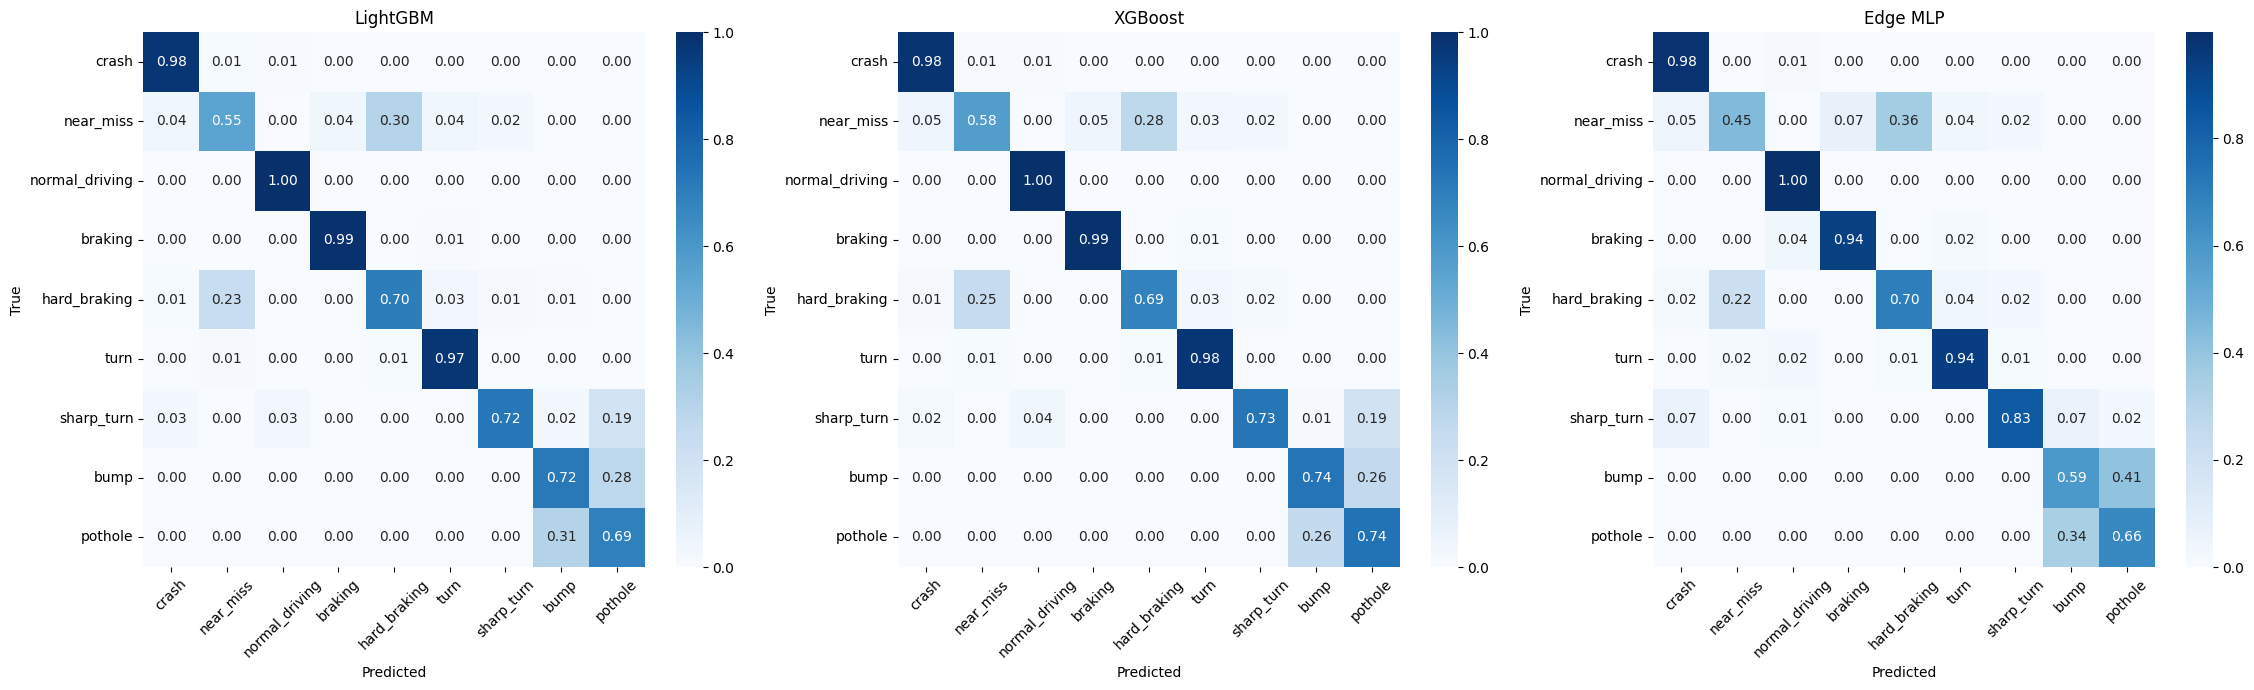

In [11]:
y_test_lgb = lgb_model.predict(X_test_raw)
y_test_xgb = xgb_model.predict(X_test_raw)
model.eval()
with torch.no_grad():
    y_test_mlp = torch.argmax(model(torch.from_numpy(X_test).to(device)), dim=1).cpu().numpy()

pred_map = {
    "LightGBM": y_test_lgb,
    "XGBoost": y_test_xgb,
    "Edge MLP": y_test_mlp,
}

test_results = pd.DataFrame([metric_row(y_test, pred, name) for name,pred in pred_map.items()])
print(test_results.to_string(index=False))

print("\n=== Edge MLP classification report ===")
print(classification_report(y_test, y_test_mlp, target_names=target_names, digits=3, zero_division=0))

fig, axes = plt.subplots(1, 3, figsize=(23, 7))
for ax, (name, pred) in zip(axes, pred_map.items()):
    cm = confusion_matrix(y_test, pred, normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=target_names, yticklabels=target_names, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(PLOT_DIR / "test_confusion_matrices.png", dpi=160)
plt.show()
plt.close()

test_results.to_csv(ARTIFACT_DIR / "test_model_comparison.csv", index=False)

## 10. Inference latency benchmark

Latency below measures **model inference only** on the current Python machine. It does not represent end-to-end Android latency, sensor collection, feature extraction, or battery usage.

In [12]:
def benchmark(fn, repeats=100):
    for _ in range(10):
        fn()
    start = time.perf_counter()
    for _ in range(repeats):
        fn()
    return (time.perf_counter() - start) / repeats * 1000

sample_raw = X_test_raw[:1]
sample_scaled = X_test[:1]
lat_lgb = benchmark(lambda: lgb_model.predict(sample_raw, num_threads=1))
lat_xgb = benchmark(lambda: xgb_model.predict(sample_raw))
model_cpu = model.eval().cpu()
lat_mlp = benchmark(lambda: model_cpu(torch.from_numpy(sample_scaled)), repeats=100)

latency_results = pd.DataFrame([
    {"model": "LightGBM", "latency_ms": lat_lgb},
    {"model": "XGBoost", "latency_ms": lat_xgb},
    {"model": "Edge MLP", "latency_ms": lat_mlp},
])
print(latency_results.to_string(index=False))
latency_results.to_csv(ARTIFACT_DIR / "inference_latency.csv", index=False)

   model  latency_ms
LightGBM    0.453614
 XGBoost    0.853400
Edge MLP    0.050400


/Users/viditagarwal/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/viditagarwal/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/viditagarwal/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/viditagarwal/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/viditagarwal/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature nam

## 11. Export the mobile deployment package

The Android/Flutter runtime must reproduce the following contract exactly:

1. Collect the same sensor units described by the master dataset metadata.
2. Create the same 1-second / 100-sample window.
3. Compute the same 62 engineered features.
4. Emit them in the exact order in `feature_contract.json`.
5. Apply the exported `scaler_params.json`.
6. Run the ONNX MLP.
7. Map the output index using `label_mapping.json`.

**The previous notebook hard-coded a 51-feature extractor. That is intentionally removed. The processed master dataset has 62 features, and the deployment contract now derives the feature count/order directly from the metadata.**

In [13]:
import shutil

# Export the best validation MLP weights for Python-side reproducibility as well.
torch.save(model_cpu.state_dict(), ARTIFACT_DIR / "driving_event_classifier_mlp_state.pt")

# ONNX is optional at notebook authoring time. The user's training environment should install onnx + onnxruntime.
try:
    import onnx
    import onnxruntime as ort

    onnx_path = ARTIFACT_DIR / "driving_event_classifier.onnx"
    dummy = torch.randn(1, len(feature_cols), dtype=torch.float32)
    torch.onnx.export(
        model_cpu,
        dummy,
        onnx_path,
        export_params=True,
        opset_version=17,
        do_constant_folding=True,
        input_names=["sensor_features_scaled"],
        output_names=["class_logits"],
        dynamic_axes={
            "sensor_features_scaled": {0: "batch_size"},
            "class_logits": {0: "batch_size"}
        }
    )

    onnx_model = onnx.load(str(onnx_path))
    onnx.checker.check_model(onnx_model)

    sample = X_test[:8].astype(np.float32)
    with torch.no_grad():
        torch_logits = model_cpu(torch.from_numpy(sample)).numpy()
    ort_session = ort.InferenceSession(str(onnx_path), providers=["CPUExecutionProvider"])
    ort_logits = ort_session.run(["class_logits"], {"sensor_features_scaled": sample})[0]
    max_diff = float(np.max(np.abs(torch_logits - ort_logits)))
    assert max_diff < 1e-4, f"ONNX parity failed: max diff={max_diff}"
    onnx_status = {"exported": True, "max_abs_logit_difference": max_diff}
    print("✓ ONNX export and runtime parity verified")
    print("Max absolute logit difference:", max_diff)
except ImportError as exc:
    onnx_status = {"exported": False, "reason": str(exc)}
    print("ONNX export skipped because onnx/onnxruntime is not installed.")
    print("Install with: pip install onnx onnxruntime")

model_config = {
    "model_name": "PhoneBlackBox-DrivingEvent-EdgeMLP",
    "version": "3.0.0",
    "dataset": {
        "total_windows": 21978,
        "train_windows": 15308,
        "validation_windows": 3268,
        "test_windows": 3402,
        "num_features": 62,
        "num_classes": 9
    },
    "classes": label_map,
    "input_features": feature_cols,
    "window": {
        "sampling_rate_hz": label_meta["sampling_rate_hz"],
        "window_size_samples": label_meta["window_size_samples"],
        "window_duration_seconds": label_meta["window_duration_seconds"]
    },
    "preprocessing": {
        "tree_models": "none",
        "edge_mlp": "StandardScaler fitted on training split only"
    },
    "validation_selection": val_results.to_dict(orient="records"),
    "test_benchmark": test_results.to_dict(orient="records"),
    "onnx": onnx_status,
    "artifacts": [
        "feature_contract.json",
        "scaler_params.json",
        "model_config.json",
        "driving_event_classifier_mlp_state.pt",
        "driving_event_classifier.onnx"
    ]
}
with open(ARTIFACT_DIR / "model_config.json", "w", encoding="utf-8") as f:
    json.dump(model_config, f, indent=2)

print("\nArtifacts written to:", ARTIFACT_DIR.resolve())
print(sorted(p.name for p in ARTIFACT_DIR.iterdir()))

✓ ONNX export and runtime parity verified
Max absolute logit difference: 1.9073486328125e-06

Artifacts written to: /Users/viditagarwal/Desktop/Phone Black Box 2/fix/artifacts_phone_black_box
['driving_event_classifier.onnx', 'driving_event_classifier_mlp_state.pt', 'feature_contract.json', 'inference_latency.csv', 'model_config.json', 'plots', 'scaler_params.json', 'test_model_comparison.csv']


/var/folders/3z/c47dtsnx7hz67hb8f_3t3lw80000gn/T/ipykernel_15938/2364885307.py:13: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


## 12. Final deployment checklist

Before integrating Phone Black Box, verify all of the following:

- [ ] Runtime window is exactly 100 samples at 100 Hz.
- [ ] Accelerometer units are m/s² and include gravity as documented.
- [ ] Gyroscope units are deg/s.
- [ ] Speed is km/h.
- [ ] Runtime feature extractor generates **exactly 62 features**.
- [ ] Runtime feature order exactly matches `feature_contract.json`.
- [ ] Runtime applies the exported training-only scaler for the MLP.
- [ ] Runtime output labels use `label_mapping.json`.
- [ ] ONNX logits match PyTorch within the verified tolerance.
- [ ] Test metrics are reported separately from validation/model selection.
- [ ] Crash recall and false-positive behavior are reviewed before any real emergency use.

### Important project limitation

This ML model is a **research/B.Tech project component**, not a certified automotive safety system. Real-world deployment would require substantially more subject/device diversity, sequence-level evaluation, false-alarm analysis, calibration, adversarial/noise testing, and safety validation.